# AutoEncoder : compression, espace latent et generation

Ce notebook demontre, avec un AutoEncoder entraine, les taches suivantes sur **deux jeux de donnees** (les chiffres MNIST et les formes colorees `shapes`) :

- compression puis decompression des images,
- visualisation de l'espace latent,
- generation de nouvelles images a partir du reseau entraine.

Il se termine en repondant explicitement aux quatre questions du projet :

1. Quelle est la nature de l'espace latent (continu, discret, ...) ?
2. Qu'est-ce que le codebook (de quoi les deux parties ont-elles besoin pour reconstruire) ?
3. Quelle est la qualite de reconstruction apres decompression ?
4. Quelle est la taille du message (code byte) apres compression ?

On construit d'abord une implementation complete de reference, puis on experimente en faisant varier les hyper-parametres (dimension latente, fonction d'activation).

In [1]:
from src.dataset import load_mnist_dataset, load_shapes_npz
from src.autoencoder import AutoEncoder
from src.helper import extract_full_dataset, get_device
from src.metrics import compression_report, Latent

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# Reproductibilite
np.random.seed(0)
torch.manual_seed(0)

print("device:", get_device())

# Hyper-parametres partages (volontairement modestes pour rester rapides sur CPU, a augmenter librement)
EPOCHS = 15
EPOCHS_SWEEP = 6
BATCH_SIZE = 128

device: cpu


In [2]:
# Fonctions d'affichage et utilitaires, definies une seule fois et reutilisees pour les deux jeux de donnees.

def to_image(flat_vector, image_shape):
    """Reshape un vecteur aplati en image affichable: (H,W) en niveaux de gris ou (H,W,C) en couleur."""
    channels, height, width = image_shape
    image = flat_vector.reshape(channels, height, width)
    return image[0] if channels == 1 else np.transpose(image, (1, 2, 0))

def show_reconstructions(originals, reconstructions, image_shape, n=8, title=None):
    """Ligne du haut: images originales; ligne du bas: reconstructions apres compression/decompression."""
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(2, n, figsize=(n * 1.3, 3))
    for i in range(n):
        axes[0, i].imshow(to_image(originals[i], image_shape), cmap=cmap)
        axes[1, i].imshow(np.clip(to_image(reconstructions[i], image_shape), 0, 1), cmap=cmap)
        for row in (0, 1):
            axes[row, i].set_xticks([]); axes[row, i].set_yticks([])
    axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("reconstruit")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

def show_gallery(flat_images, image_shape, nrow=4, ncol=8, title=None):
    """Grille d'images, utilisee pour afficher les images generees."""
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 1.1, nrow * 1.1))
    for i, ax in enumerate(np.atleast_1d(axes).ravel()):
        ax.axis("off")
        if i < len(flat_images):
            ax.imshow(np.clip(to_image(flat_images[i], image_shape), 0, 1), cmap=cmap)
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

def plot_latent_scatter(latent_2d, labels, class_names=None, title=None):
    """Nuage de points de l'espace latent 2D, colore par classe."""
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap="tab10", s=6, alpha=0.6)
    if class_names is not None:
        handles, _ = scatter.legend_elements()
        plt.legend(handles, class_names, title="classe", bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        plt.colorbar(scatter, label="chiffre")
    plt.xlabel("z1"); plt.ylabel("z2")
    if title:
        plt.title(title)
    plt.tight_layout(); plt.show()

def print_report(report):
    """Affiche proprement le dictionnaire renvoye par compression_report."""
    for key, value in report.items():
        print(f"{key:>24}: {value:,.4f}" if isinstance(value, float) else f"{key:>24}: {value}")

def sample_gaussian_latent(latent_codes, n_samples, seed=0):
    """Ajuste une gaussienne (moyenne + covariance) sur les codes latents et en tire de nouveaux points."""
    rng = np.random.default_rng(seed)
    mean = latent_codes.mean(axis=0)
    cov = np.cov(latent_codes, rowvar=False)
    return rng.multivariate_normal(mean, cov, size=n_samples).astype(np.float32)

def interpolate_latent(z_start, z_end, steps=10):
    """Interpolation lineaire entre deux codes latents."""
    alphas = np.linspace(0, 1, steps)[:, None]
    return ((1 - alphas) * z_start[None, :] + alphas * z_end[None, :]).astype(np.float32)

def run_experiment(X_train, X_eval, input_dim, latent_dim, activation, epochs):
    """Entraine un AutoEncoder et renvoie le rapport de compression sur le jeu d'evaluation."""
    model = AutoEncoder(input_dim=input_dim, output_dim=input_dim, latent_dim=latent_dim,
                        encoder_layer_num=3, decoder_layer_num=3, encoder_activation=activation)
    model.fit(X_train, epochs=epochs, batch_size=BATCH_SIZE)
    latent = model.encode(X_eval)
    reconstruction = model.decode(latent)
    return compression_report(model.get_codebook(), latent, X_eval, reconstruction)

def subsample(images, labels, n, seed=0):
    """Sous-echantillon reproductible de n exemples."""
    if n >= len(images):
        return images, labels
    idx = np.random.default_rng(seed).choice(len(images), size=n, replace=False)
    return images[idx], labels[idx]

## Partie A - Chiffres MNIST

Images 28x28 en niveaux de gris, aplaties en vecteurs de 784 valeurs pour l'AutoEncoder lineaire.

In [3]:
# Chargement MNIST (shuffle=False pour un sous-echantillon reproductible) puis aplatissement en (N, 784)
mnist_train_images, mnist_train_labels = extract_full_dataset(load_mnist_dataset(train=True, shuffle=False))
mnist_eval_images, mnist_eval_labels = extract_full_dataset(load_mnist_dataset(train=False, shuffle=False))

MNIST_SHAPE = (1, 28, 28)
X_mnist_train, y_mnist_train = subsample(
    mnist_train_images.reshape(len(mnist_train_images), -1).numpy(), mnist_train_labels.numpy(), 15000)
X_mnist_eval, y_mnist_eval = subsample(
    mnist_eval_images.reshape(len(mnist_eval_images), -1).numpy(), mnist_eval_labels.numpy(), 3000)
print("train:", X_mnist_train.shape, "| eval:", X_mnist_eval.shape)

train: (15000, 784) | eval: (3000, 784)


### A1. Entrainement du modele de reference

AutoEncoder lineaire, activation ReLU, dimension latente 32 (compression 784 -> 32).

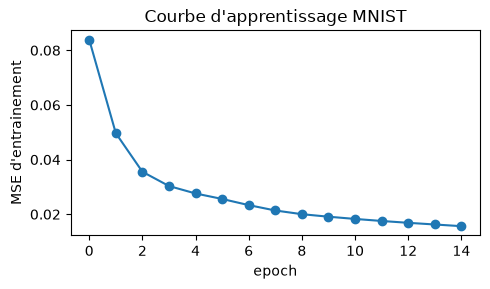

In [4]:
mnist_model = AutoEncoder(input_dim=784, output_dim=784, latent_dim=32,
                          encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU)
mnist_model.fit(X_mnist_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

plt.figure(figsize=(5, 3))
plt.plot(mnist_model.loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE d'entrainement"); plt.title("Courbe d'apprentissage MNIST")
plt.tight_layout(); plt.show()

### A2. Compression et decompression

`encode` projette chaque image dans l'espace latent (compression), `decode` reconstruit l'image (decompression).

code latent par image: 32 valeurs | nature: continuous


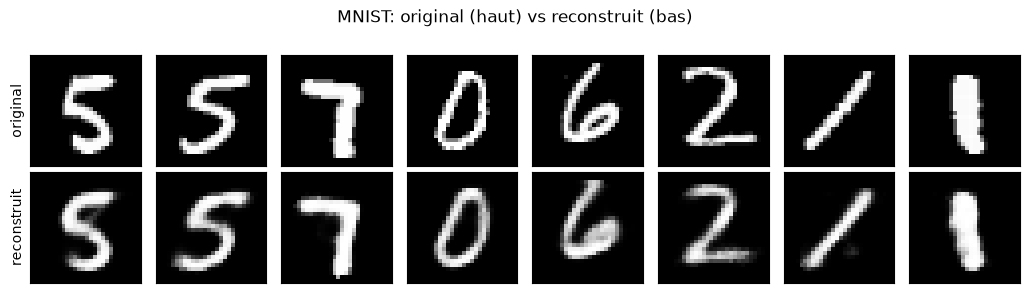

In [5]:
mnist_latent = mnist_model.encode(X_mnist_eval)
mnist_reconstructed = mnist_model.decode(mnist_latent)
print("code latent par image:", mnist_latent.array.shape[1], "valeurs | nature:", mnist_latent.nature)
show_reconstructions(X_mnist_eval, mnist_reconstructed, MNIST_SHAPE, n=8,
                     title="MNIST: original (haut) vs reconstruit (bas)")

### A3. Qualite de reconstruction et taille du message (code byte)

Toutes les metriques proviennent de la fonction centralisee `compression_report`.

In [6]:
mnist_report = compression_report(mnist_model.get_codebook(), mnist_latent, X_mnist_eval, mnist_reconstructed)
print_report(mnist_report)

per_image_bytes = mnist_latent.n_bytes / len(X_mnist_eval)
print(f"\nMessage transmis par image: {per_image_bytes:.0f} octets ({mnist_latent.array.shape[1]} float32),")
print(f"contre {X_mnist_eval[0].nbytes} octets pour l'image originale en float32.")
print(f"Codebook (poids du decodeur): {mnist_report['codebook_bytes']:,} octets, partage une seule fois.")

           latent_nature: continuous
          codebook_bytes: 958932
            latent_bytes: 384000
  total_compressed_bytes: 1342932
          original_bytes: 9408000
       compression_ratio: 7.0056
      reconstruction_mse: 0.0154

Message transmis par image: 128 octets (32 float32),
contre 3136 octets pour l'image originale en float32.
Codebook (poids du decodeur): 958,932 octets, partage une seule fois.


### A4. Visualisation de l'espace latent

L'espace latent est **continu**: chaque image devient un vecteur de reels. Pour le visualiser directement, on entraine un second AutoEncoder de dimension latente 2 et on affiche les codes, colores par chiffre.

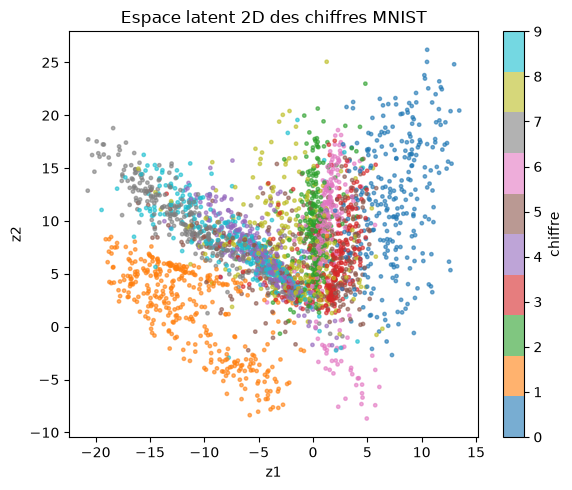

In [7]:
mnist_model_2d = AutoEncoder(input_dim=784, output_dim=784, latent_dim=2,
                             encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU)
mnist_model_2d.fit(X_mnist_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

mnist_latent_2d = mnist_model_2d.encode(X_mnist_eval).array
plot_latent_scatter(mnist_latent_2d, y_mnist_eval, title="Espace latent 2D des chiffres MNIST")

### A5. Generation de nouvelles images

Le decodeur seul est un generateur: on lui fournit des codes latents inedits.

- **Echantillonnage gaussien**: on ajuste une gaussienne sur les codes du jeu d'evaluation et on en tire de nouveaux.
- **Interpolation**: on relie deux images reelles par une droite dans l'espace latent.
- **Balayage de la variete 2D**: on decode une grille reguliere du plan latent du modele 2D.

Note: un AutoEncoder classique ne contraint pas son espace latent a une loi connue; rester pres de la distribution des donnees (gaussienne ajustee, interpolation) donne les images les plus nettes.

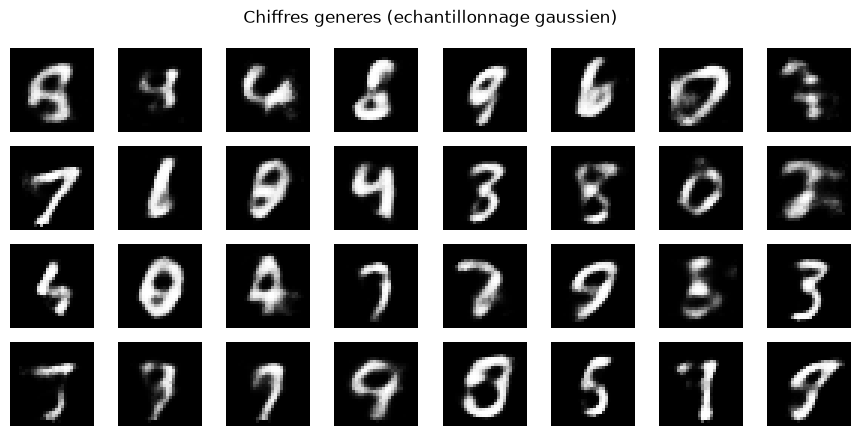

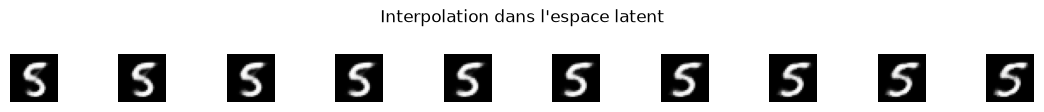

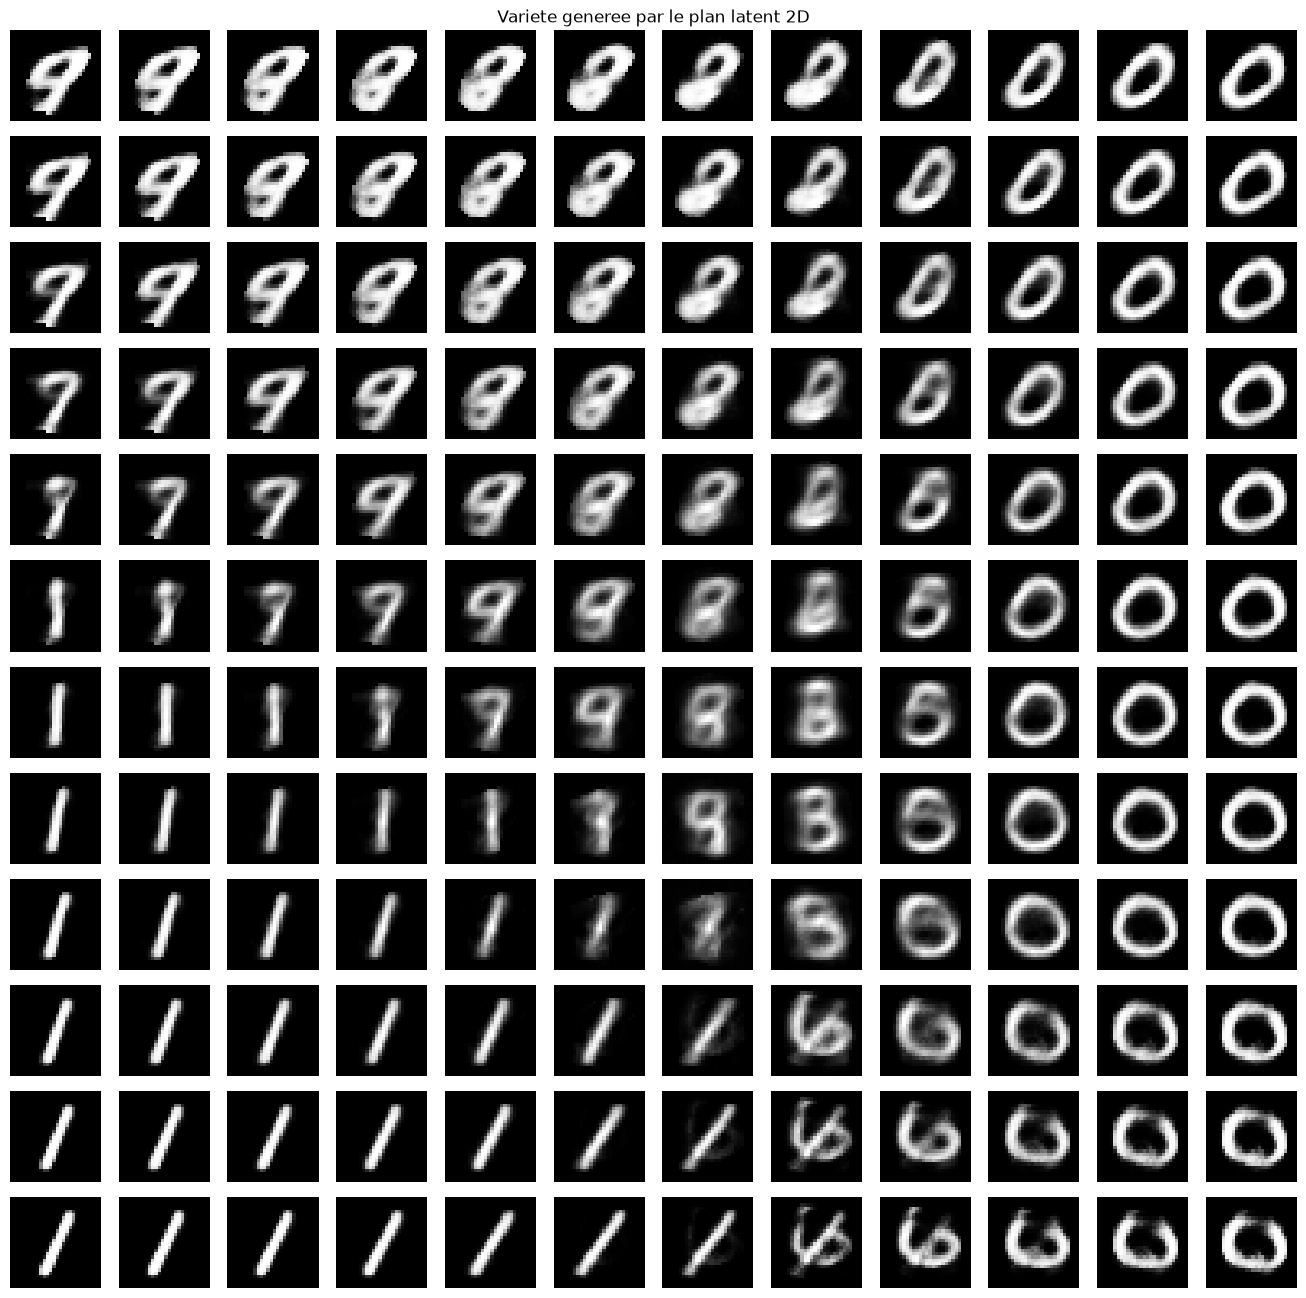

In [8]:
# 1) Echantillonnage gaussien depuis le modele de reference (latent 32D)
new_codes = sample_gaussian_latent(mnist_latent.array, n_samples=32)
generated = mnist_model.decode(Latent(array=new_codes, nature="continuous"))
show_gallery(generated, MNIST_SHAPE, nrow=4, ncol=8, title="Chiffres generes (echantillonnage gaussien)")

# 2) Interpolation entre deux images
path = interpolate_latent(mnist_latent.array[0], mnist_latent.array[1], steps=10)
morph = mnist_model.decode(Latent(array=path, nature="continuous"))
show_gallery(morph, MNIST_SHAPE, nrow=1, ncol=10, title="Interpolation dans l'espace latent")

# 3) Balayage de la variete 2D (modele latent 2D)
lo, hi = mnist_latent_2d.min(axis=0), mnist_latent_2d.max(axis=0)
grid_axis = 12
xs = np.linspace(lo[0], hi[0], grid_axis)
ys = np.linspace(hi[1], lo[1], grid_axis)
grid = np.array([[x, y] for y in ys for x in xs], dtype=np.float32)
manifold = mnist_model_2d.decode(Latent(array=grid, nature="continuous"))
show_gallery(manifold, MNIST_SHAPE, nrow=grid_axis, ncol=grid_axis, title="Variete generee par le plan latent 2D")

### A6. Experimentation sur les hyper-parametres

On fait varier la dimension latente et la fonction d'activation, puis on compare la qualite de reconstruction (MSE) et la taille totale compressee.

 ReLU | latent= 2 | MSE=0.0573 | total=  369,276 o | ratio=25.48


 ReLU | latent= 8 | MSE=0.0507 | total=  658,712 o | ratio=14.28


 ReLU | latent=16 | MSE=0.0426 | total=  920,688 o | ratio=10.22


 ReLU | latent=32 | MSE=0.0365 | total=1,342,932 o | ratio=7.01


 ReLU | latent=64 | MSE=0.0342 | total=2,076,876 o | ratio=4.53


 Tanh | latent= 2 | MSE=0.0673 | total=  369,276 o | ratio=25.48


 Tanh | latent= 8 | MSE=0.0635 | total=  658,712 o | ratio=14.28


 Tanh | latent=16 | MSE=0.0598 | total=  920,688 o | ratio=10.22


 Tanh | latent=32 | MSE=0.0624 | total=1,342,932 o | ratio=7.01


 Tanh | latent=64 | MSE=0.0675 | total=2,076,876 o | ratio=4.53


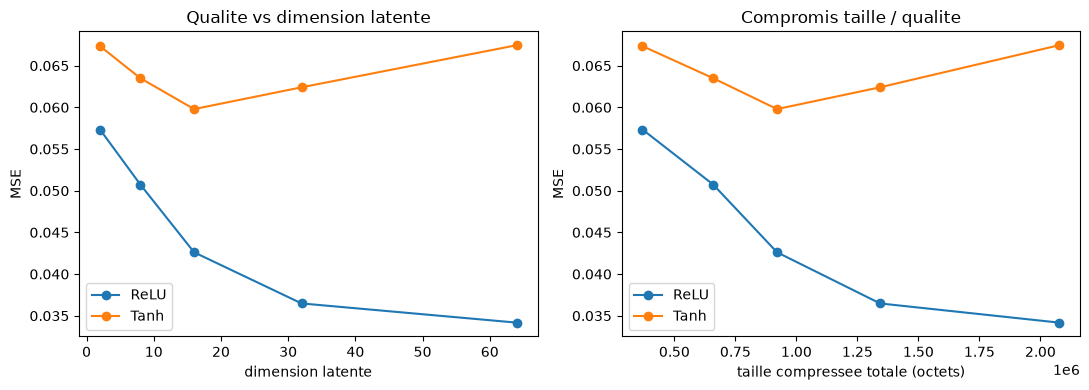

In [9]:
latent_dims = [2, 8, 16, 32, 64]
activations = {"ReLU": nn.ReLU, "Tanh": nn.Tanh}
X_tr, y_tr = subsample(X_mnist_train, y_mnist_train, 6000, seed=1)

mnist_results = []
for act_name, act in activations.items():
    for latent_dim in latent_dims:
        report = run_experiment(X_tr, X_mnist_eval, 784, latent_dim, act, EPOCHS_SWEEP)
        report.update(latent_dim=latent_dim, activation=act_name)
        mnist_results.append(report)
        print(f"{act_name:>5} | latent={latent_dim:>2} | MSE={report['reconstruction_mse']:.4f} "
              f"| total={report['total_compressed_bytes']:>9,} o | ratio={report['compression_ratio']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for act_name in activations:
    pts = [r for r in mnist_results if r["activation"] == act_name]
    axes[0].plot([r["latent_dim"] for r in pts], [r["reconstruction_mse"] for r in pts], marker="o", label=act_name)
    axes[1].plot([r["total_compressed_bytes"] for r in pts], [r["reconstruction_mse"] for r in pts], marker="o", label=act_name)
axes[0].set_xlabel("dimension latente"); axes[0].set_ylabel("MSE"); axes[0].set_title("Qualite vs dimension latente"); axes[0].legend()
axes[1].set_xlabel("taille compressee totale (octets)"); axes[1].set_ylabel("MSE"); axes[1].set_title("Compromis taille / qualite"); axes[1].legend()
plt.tight_layout(); plt.show()

## Partie B - Formes colorees (shapes)

Images 32x32 en couleur (RGB), 6 classes de formes. On charge directement les archives `.npz` (images propres et uniformes) via `load_shapes_npz`, puis on aplati en vecteurs de 3072 valeurs.

train: (12000, 3072) | eval: (3000, 3072) | classes: ['circle', 'square', 'triangle', 'cross', 'star', 'bar']


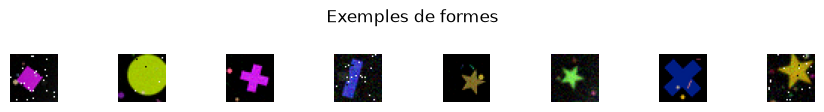

In [10]:
X_shapes_train, y_shapes_train, shape_names = load_shapes_npz(split="train", max_samples=12000)
X_shapes_eval, y_shapes_eval, _ = load_shapes_npz(split="validation", max_samples=3000)
X_shapes_train = X_shapes_train.reshape(len(X_shapes_train), -1)
X_shapes_eval = X_shapes_eval.reshape(len(X_shapes_eval), -1)

SHAPES_SHAPE = (3, 32, 32)
SHAPES_DIM = 3 * 32 * 32
print("train:", X_shapes_train.shape, "| eval:", X_shapes_eval.shape, "| classes:", shape_names)
show_gallery(X_shapes_eval[:8], SHAPES_SHAPE, nrow=1, ncol=8, title="Exemples de formes")

### B1. Entrainement, compression et decompression

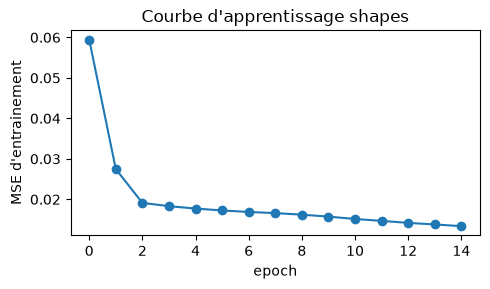

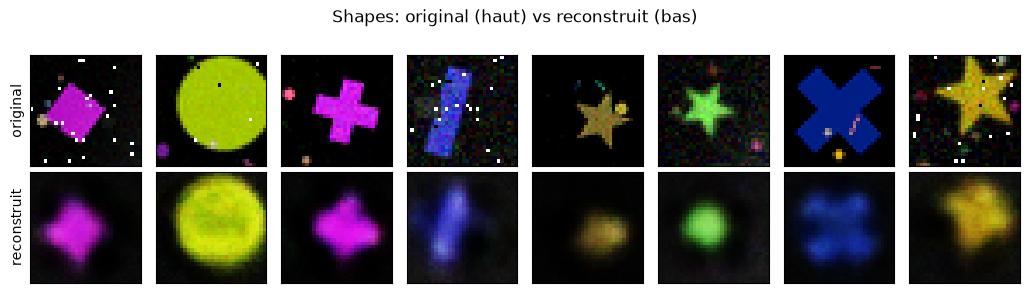

In [11]:
shapes_model = AutoEncoder(input_dim=SHAPES_DIM, output_dim=SHAPES_DIM, latent_dim=32,
                           encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU)
shapes_model.fit(X_shapes_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

plt.figure(figsize=(5, 3))
plt.plot(shapes_model.loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE d'entrainement"); plt.title("Courbe d'apprentissage shapes")
plt.tight_layout(); plt.show()

shapes_latent = shapes_model.encode(X_shapes_eval)
shapes_reconstructed = shapes_model.decode(shapes_latent)
show_reconstructions(X_shapes_eval, shapes_reconstructed, SHAPES_SHAPE, n=8,
                     title="Shapes: original (haut) vs reconstruit (bas)")

### B2. Metriques de compression

In [12]:
shapes_report = compression_report(shapes_model.get_codebook(), shapes_latent, X_shapes_eval, shapes_reconstructed)
print_report(shapes_report)

per_image_bytes = shapes_latent.n_bytes / len(X_shapes_eval)
print(f"\nMessage par image: {per_image_bytes:.0f} octets contre {X_shapes_eval[0].nbytes} octets en float32.")

           latent_nature: continuous
          codebook_bytes: 8658480
            latent_bytes: 384000
  total_compressed_bytes: 9042480
          original_bytes: 36864000
       compression_ratio: 4.0768
      reconstruction_mse: 0.0136

Message par image: 128 octets contre 12288 octets en float32.


### B3. Espace latent et generation

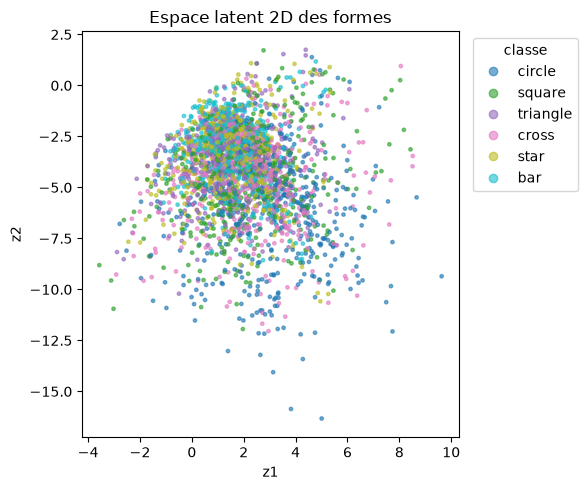

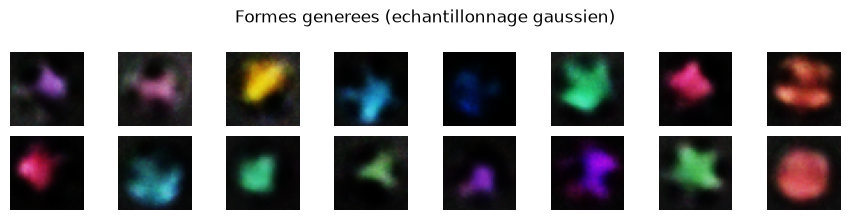

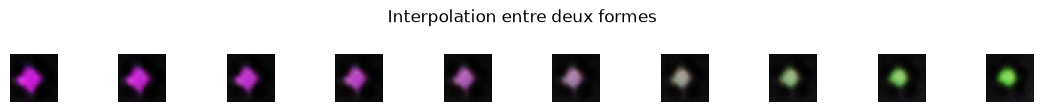

In [13]:
shapes_model_2d = AutoEncoder(input_dim=SHAPES_DIM, output_dim=SHAPES_DIM, latent_dim=2,
                              encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU)
shapes_model_2d.fit(X_shapes_train, epochs=EPOCHS, batch_size=BATCH_SIZE)
shapes_latent_2d = shapes_model_2d.encode(X_shapes_eval).array
plot_latent_scatter(shapes_latent_2d, y_shapes_eval, class_names=shape_names,
                    title="Espace latent 2D des formes")

# Generation par echantillonnage gaussien
new_codes = sample_gaussian_latent(shapes_latent.array, n_samples=16)
generated = shapes_model.decode(Latent(array=new_codes, nature="continuous"))
show_gallery(generated, SHAPES_SHAPE, nrow=2, ncol=8, title="Formes generees (echantillonnage gaussien)")

# Interpolation entre deux formes
path = interpolate_latent(shapes_latent.array[0], shapes_latent.array[5], steps=10)
morph = shapes_model.decode(Latent(array=path, nature="continuous"))
show_gallery(morph, SHAPES_SHAPE, nrow=1, ncol=10, title="Interpolation entre deux formes")

### B4. Experimentation hyper-parametres (shapes)

latent= 2 | MSE=0.0302 | total=3,330,708 o | ratio=11.07


latent= 8 | MSE=0.0195 | total=5,395,504 o | ratio=6.83


latent=16 | MSE=0.0187 | total=6,945,664 o | ratio=5.31


latent=32 | MSE=0.0186 | total=9,042,480 o | ratio=4.08


latent=64 | MSE=0.0185 | total=12,011,508 o | ratio=3.07


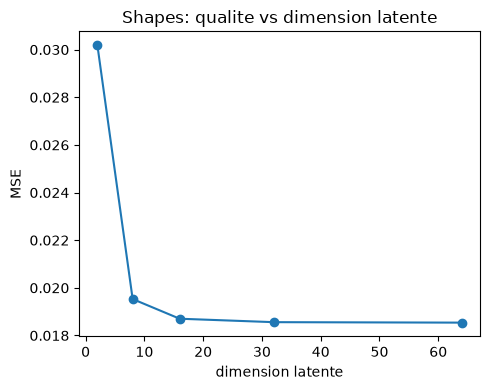

In [14]:
X_shapes_tr, _ = subsample(X_shapes_train, y_shapes_train, 6000, seed=1)
shapes_results = []
for latent_dim in [2, 8, 16, 32, 64]:
    report = run_experiment(X_shapes_tr, X_shapes_eval, SHAPES_DIM, latent_dim, nn.ReLU, EPOCHS_SWEEP)
    report.update(latent_dim=latent_dim)
    shapes_results.append(report)
    print(f"latent={latent_dim:>2} | MSE={report['reconstruction_mse']:.4f} "
          f"| total={report['total_compressed_bytes']:>9,} o | ratio={report['compression_ratio']:.2f}")

plt.figure(figsize=(5, 4))
plt.plot([r["latent_dim"] for r in shapes_results], [r["reconstruction_mse"] for r in shapes_results], marker="o")
plt.xlabel("dimension latente"); plt.ylabel("MSE"); plt.title("Shapes: qualite vs dimension latente")
plt.tight_layout(); plt.show()

## Reponses aux questions du projet

**1. Nature de l'espace latent.** Il est **continu**: `encode` renvoie un `Latent` de nature `"continuous"`, c'est-a-dire un vecteur de reels (float32) dense. N'importe quel point de l'espace peut etre decode, ce qui rend possibles l'interpolation et l'echantillonnage. Cela contraste avec K-Means, dont l'espace latent est **discret** (un indice de cluster parmi K).

**2. Codebook.** Le codebook renvoye par `get_codebook` regroupe les **poids du decodeur**. C'est le dictionnaire partage: l'emetteur et le recepteur doivent tous deux en disposer pour reconstruire. Concretement, l'emetteur compresse avec l'encodeur et n'envoie que le code latent; le recepteur applique le decodeur (le codebook) a ce code. Le codebook est un cout fixe, paye une seule fois et amorti sur toutes les images.

**3. Qualite de reconstruction.** Mesuree par la MSE de `compression_report` (voir les tableaux ci-dessus) et visible sur les grilles original vs reconstruit. Elle s'ameliore quand la dimension latente augmente, au prix d'un message plus gros: c'est le compromis illustre par les courbes d'experimentation.

**4. Code byte (taille du message).** Le message transmis par image est le code latent: `dimension_latente x 4 octets` (float32), soit par exemple 128 octets pour une dimension latente de 32. La taille totale pour un lot est `latent_bytes` dans `compression_report`; le codebook s'y ajoute une seule fois, independamment du nombre d'images.